# Memory Management

Memory allows agents to retain information across interactions. **Short-term memory** holds the current conversation context; **long-term memory** persists facts, preferences, and knowledge across sessions.

## Implementation with Flyte v2 + the Agent harness

This notebook pairs `flyte.ai.agents.MemoryStore` with an `Agent`. The store keys memory to a session id in object storage; passing it as `Agent(memory=store)` means the **conversation transcript is read and written for you** — the agent loads `store.messages` as history and appends each turn automatically. Long-term facts are kept as a named JSON artifact in the same store, with optimistic concurrency via `expected_sha`.

#### LangChain / LangGraph vs Flyte v2 + Agent harness

| Aspect | LangChain / LangGraph | Flyte v2 + `Agent` harness |
|--------|----------------------|----------------------------|
| **Transcript** | `ConversationBufferMemory`, manual append | `Agent(memory=store)` appends `store.messages` automatically |
| **Short-term memory** | In-process, lost on restart | `store.messages` — auto-persisted to object storage |
| **Long-term memory** | LangGraph `InMemoryStore` (ephemeral) | `store.write_json("profile.json", ...)` — named artifact |
| **Concurrency** | None | `expected_sha` → `ConcurrencyError` on stale writes |
| **Observability** | Log parsing | Audit log (`store.audit_tail()`): actor, sha256, timestamp |
| **Secrets** | `.env` / `os.environ` | `flyte.Secret` injected by cluster |

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use memory when the agent must do more than answer once — hold context across a conversation, track progress on a multi-step task, or personalize from past interactions. Flyte's `MemoryStore` keys the transcript and long-term artifacts to a session id in object storage, so any pod can reload the exact state, with an audit log and optimistic-concurrency guards built in.

### 1. Install dependencies

In [ ]:
!uv pip install 'flyte[tui]' litellm

### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [23]:
import json
import os
from dataclasses import dataclass, field
from datetime import timedelta

import flyte
from flyte.ai.agents import Agent, AgentResult, MemoryStore, ConcurrencyError

flyte.init_from_config()

_image = (
    flyte.Image.from_debian_base(name="memory-agent", python_version=(3, 12))
    .with_pip_packages("litellm")
)

memory_env = flyte.TaskEnvironment(
    name="memory_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
)

### 4. Define the long-term profile model

`UserProfile` is a local helper dataclass used **inside** the task — it never appears in the Flyte type signature, so there are no serializer constraints on its fields. The short-term transcript no longer needs a dataclass: pairing the `Agent` with the store means `store.messages` is managed for us.

`MemoryStore` handles persistence: the transcript lives in `store.messages` (written by the agent), and `UserProfile` is saved as `profile.json` via `write_json()`. Both survive pod restarts because the store is keyed to the session id in object storage.

```
<storage_root>/agents/memory-store/v0/{org}/{project}/{domain}/{session_key}/
    messages.json       ← transcript (store.messages, written by Agent(memory=store))
    profile.json        ← UserProfile artifact
    audit/log.jsonl     ← every write: actor, sha256, timestamp, reason
```
[Learn more about Flyte's MemoryStore](https://www.union.ai/docs/v2/union/api-reference/flyte-sdk/packages/flyte.ai.agents/memorystore/)

In [24]:
@dataclass
class UserProfile:
    """Long-term: user facts that persist across sessions. Replaces LangGraph InMemoryStore."""
    name: str = ""
    preferences: dict[str, str] = field(default_factory=dict)
    visited_places: list[str] = field(default_factory=list)

    def remember(self, key: str, value: str) -> "UserProfile":
        return UserProfile(
            name=self.name,
            preferences={**self.preferences, key: value},
            visited_places=self.visited_places,
        )

    def add_visit(self, place: str) -> "UserProfile":
        return UserProfile(
            name=self.name,
            preferences=self.preferences,
            visited_places=self.visited_places + [place],
        )

    def summary(self) -> str:
        if not self.preferences and not self.visited_places:
            return "No user profile information available."
        parts = []
        if self.name:
            parts.append(f"User: {self.name}")
        if self.preferences:
            parts.append("Preferences: " + ", ".join(f"{k}={v}" for k, v in self.preferences.items()))
        if self.visited_places:
            parts.append("Previously visited: " + ", ".join(self.visited_places))
        return ". ".join(parts)

### 5. Define the travel agent task

`chat_turn` takes `user_message` and `session_key` and returns the agent's reply. Memory flows through `MemoryStore`:

1. `MemoryStore.get_or_create.aio(key=session_key)` — loads the store on turns 2+, creates it on turn 1.
2. `store.read_json("profile.json")` — rehydrates `UserProfile` (long-term).
3. `Agent(memory=store)` — the agent reads `store.messages` as history and **appends this turn's user + assistant messages automatically** (short-term). No manual `store.append` / `_chat` helper.
4. `store.write_json("profile.json", ...)` — persists updated facts (long-term artifact).
5. `store.save.aio()` — flushes transcript + artifacts to the keyed path in object storage.

**Difference from LangChain:** `ConversationBufferMemory` is in-process — gone on restart. `MemoryStore` keys memory to a session id; any task, on any pod, can reload the exact same store from just the key.

In [25]:
TRAVEL_AGENT_SYSTEM = """\
You are a friendly travel agent with excellent memory. Help the user plan trips.
When the user mentions a preference (budget, travel style, food, etc.), acknowledge it.
When they mention a place they've visited, acknowledge it.
Keep responses concise (2-3 sentences max)."""

PROFILE_EXTRACTOR_SYSTEM = """\
Extract structured facts from this conversation turn.
Respond ONLY with JSON in this exact format:
{"name": "<user name if mentioned, else empty string>",
 "preference_key": "<one preference key if any, else empty string>",
 "preference_value": "<preference value, else empty string>",
 "visited_place": "<place name if user mentioned visiting, else empty string>"}"""


# Long-term fact extractor: a tiny, stateless Agent (no memory attached).
profile_extractor = Agent(
    name="profile-extractor",
    model="claude-haiku-4-5",
    instructions=PROFILE_EXTRACTOR_SYSTEM,
)


@flyte.trace
async def _extract_facts(user_message: str, agent_response: str) -> dict:
    result = await profile_extractor.run.aio(
        f"User said: {user_message}\nAgent replied: {agent_response}"
    )
    raw = (result.summary or "").strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    try:
        return json.loads(raw)
    except Exception:
        return {}


@memory_env.task(
    retries=2,
    timeout=timedelta(minutes=5),
    cache=flyte.Cache(behavior="disable"),
)
async def chat_turn(user_message: str, session_key: str) -> str:
    """One conversation turn with MemoryStore-backed memory.

    The Agent manages the transcript (store.messages); we manage the long-term profile.
    """
    store = await MemoryStore.get_or_create.aio(key=session_key)

    # Long-term memory: rehydrate the profile artifact.
    profile_data = await store.read_json.aio("profile.json", default={})
    profile = UserProfile(
        name=profile_data.get("name", ""),
        preferences=profile_data.get("preferences", {}),
        visited_places=profile_data.get("visited_places", []),
    )

    profile_context = profile.summary()
    system = TRAVEL_AGENT_SYSTEM
    if profile_context != "No user profile information available.":
        system += f"\n\nKnown user context: {profile_context}"

    # Short-term memory: the Agent loads store.messages as history and appends this
    # turn's user + assistant messages automatically.
    agent = Agent(
        name="travel-agent",
        model="claude-haiku-4-5",
        instructions=system,
        memory=store,
    )
    result: AgentResult = await agent.run.aio(user_message)
    response = result.summary or ""

    # Long-term memory: extract durable facts and persist them as a named artifact.
    facts = await _extract_facts(user_message=user_message, agent_response=response)
    if facts.get("name"):
        profile = UserProfile(name=facts["name"], preferences=profile.preferences, visited_places=profile.visited_places)
    if facts.get("preference_key") and facts.get("preference_value"):
        profile = profile.remember(facts["preference_key"], facts["preference_value"])
    if facts.get("visited_place"):
        profile = profile.add_visit(facts["visited_place"])

    # Describe *what changed* in the audit reason instead of logging the raw prompt,
    # so user text never lands in the audit log (audit/log.jsonl).
    changed = []
    if facts.get("name"):
        changed.append("name")
    if facts.get("preference_key"):
        changed.append(f"pref:{facts['preference_key']}")
    if facts.get("visited_place"):
        changed.append("visit")
    reason = "profile update (" + (", ".join(changed) or "no new facts") + ")"

    await store.write_json.aio(
        "profile.json",
        {"name": profile.name, "preferences": profile.preferences, "visited_places": profile.visited_places},
        actor="chat_turn",
        reason=reason,
    )
    await store.save.aio()
    return response

### 6. Run a multi-turn conversation

Each `flyte.run.aio()` call dispatches a single turn. The run loop no longer tracks any memory state — `session_key` is the only thread between turns. `MemoryStore.get_or_create` inside `chat_turn` does the rest.

In [26]:
CONVERSATION = [
    "Hi! I'm planning a trip and could use some help.",
    "I love budget travel and prefer hostels over hotels.",
    "I visited Tokyo last year and it was amazing.",
    "What would you recommend for Southeast Asia on a tight budget?",
    "I'm a vegetarian, so food options matter a lot to me.",
]
SESSION_KEY = "travel-agent-david"

for i, user_msg in enumerate(CONVERSATION, 1):
    print(f"─── Turn {i} " + "─" * 50)
    print(f"User: {user_msg}")

    run = await flyte.run.aio(chat_turn, user_message=user_msg, session_key=SESSION_KEY)
    await run.wait.aio()
    response: str = run.outputs()[0]

    print(f"Agent: {response}")
    print(f"Run:   {run.url}")
    print()

─── Turn 1 ──────────────────────────────────────────────────
User: Hi! I'm planning a trip and could use some help.


> Building 1 image...

> Building image memory-agent for environment memory_agent

✓ Built image for environment memory_agent: localhost:30000/memory-agent:c0e0f4726ed0c807007057a3d5d61d37

Output()

...

> Building 1 image...

> Building image memory-agent for environment memory_agent

✓ Built image for environment memory_agent: localhost:30000/memory-agent:c0e0f4726ed0c807007057a3d5d61d37

Output()

Agent: I know—you've emphasized that a few times, and it's important! Southeast Asia will be fantastic for you since vegetarian food is cheap, delicious, and everywhere. Let's nail down your itinerary: are you leaning toward Thailand, Vietnam, Cambodia, or a mix of countries?
Run:   http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rqhmk6m8vqwdn65bt9hr



Each chat turn is a discrete execution:

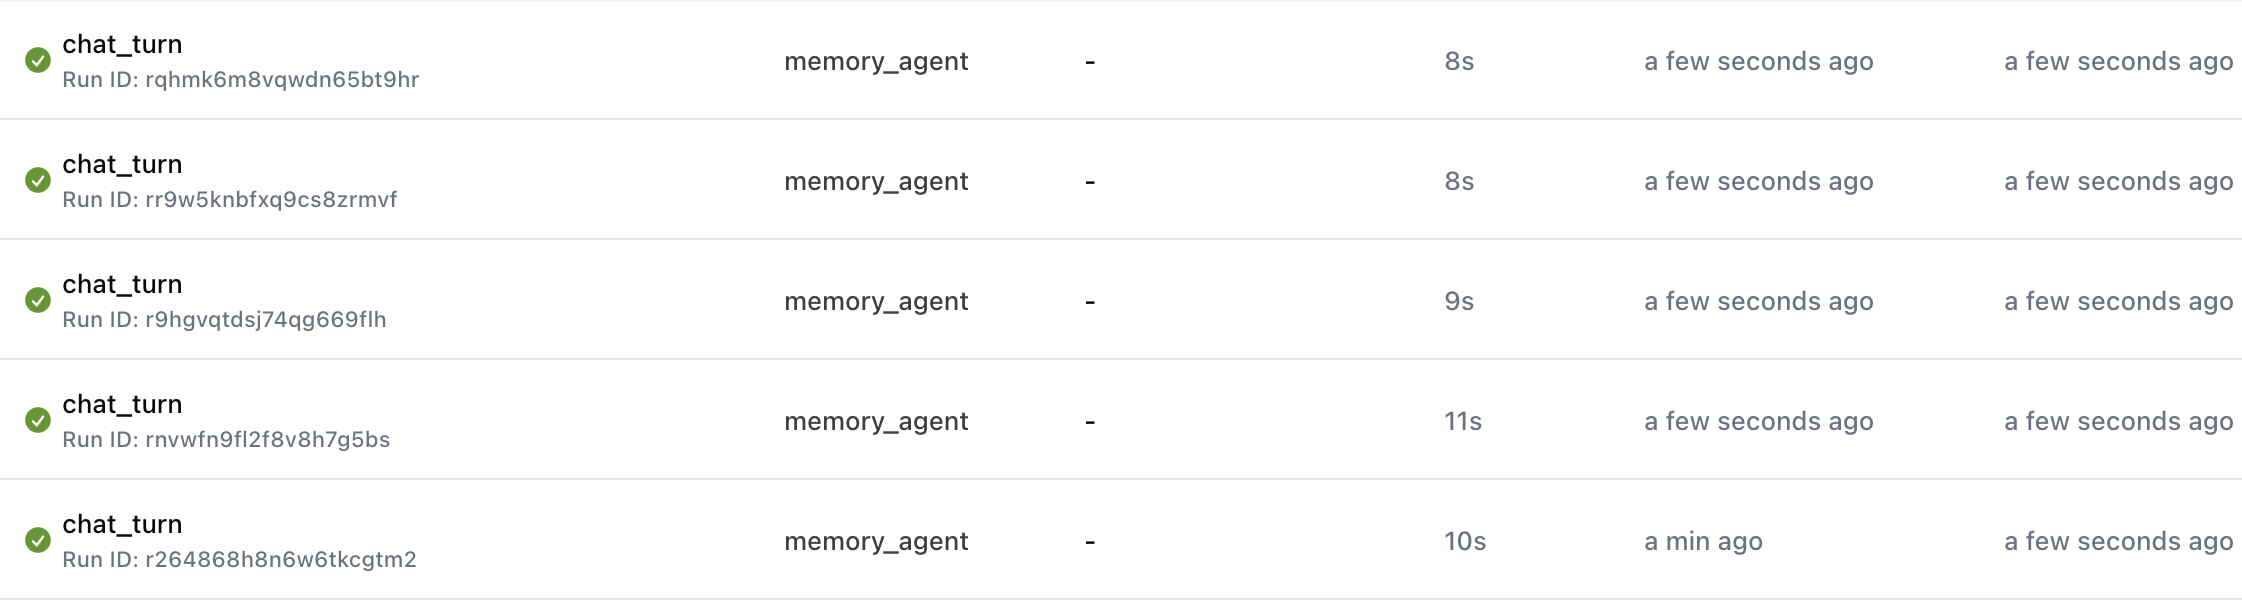

Quick output inspection shows the user profile is retained throughout conversations:

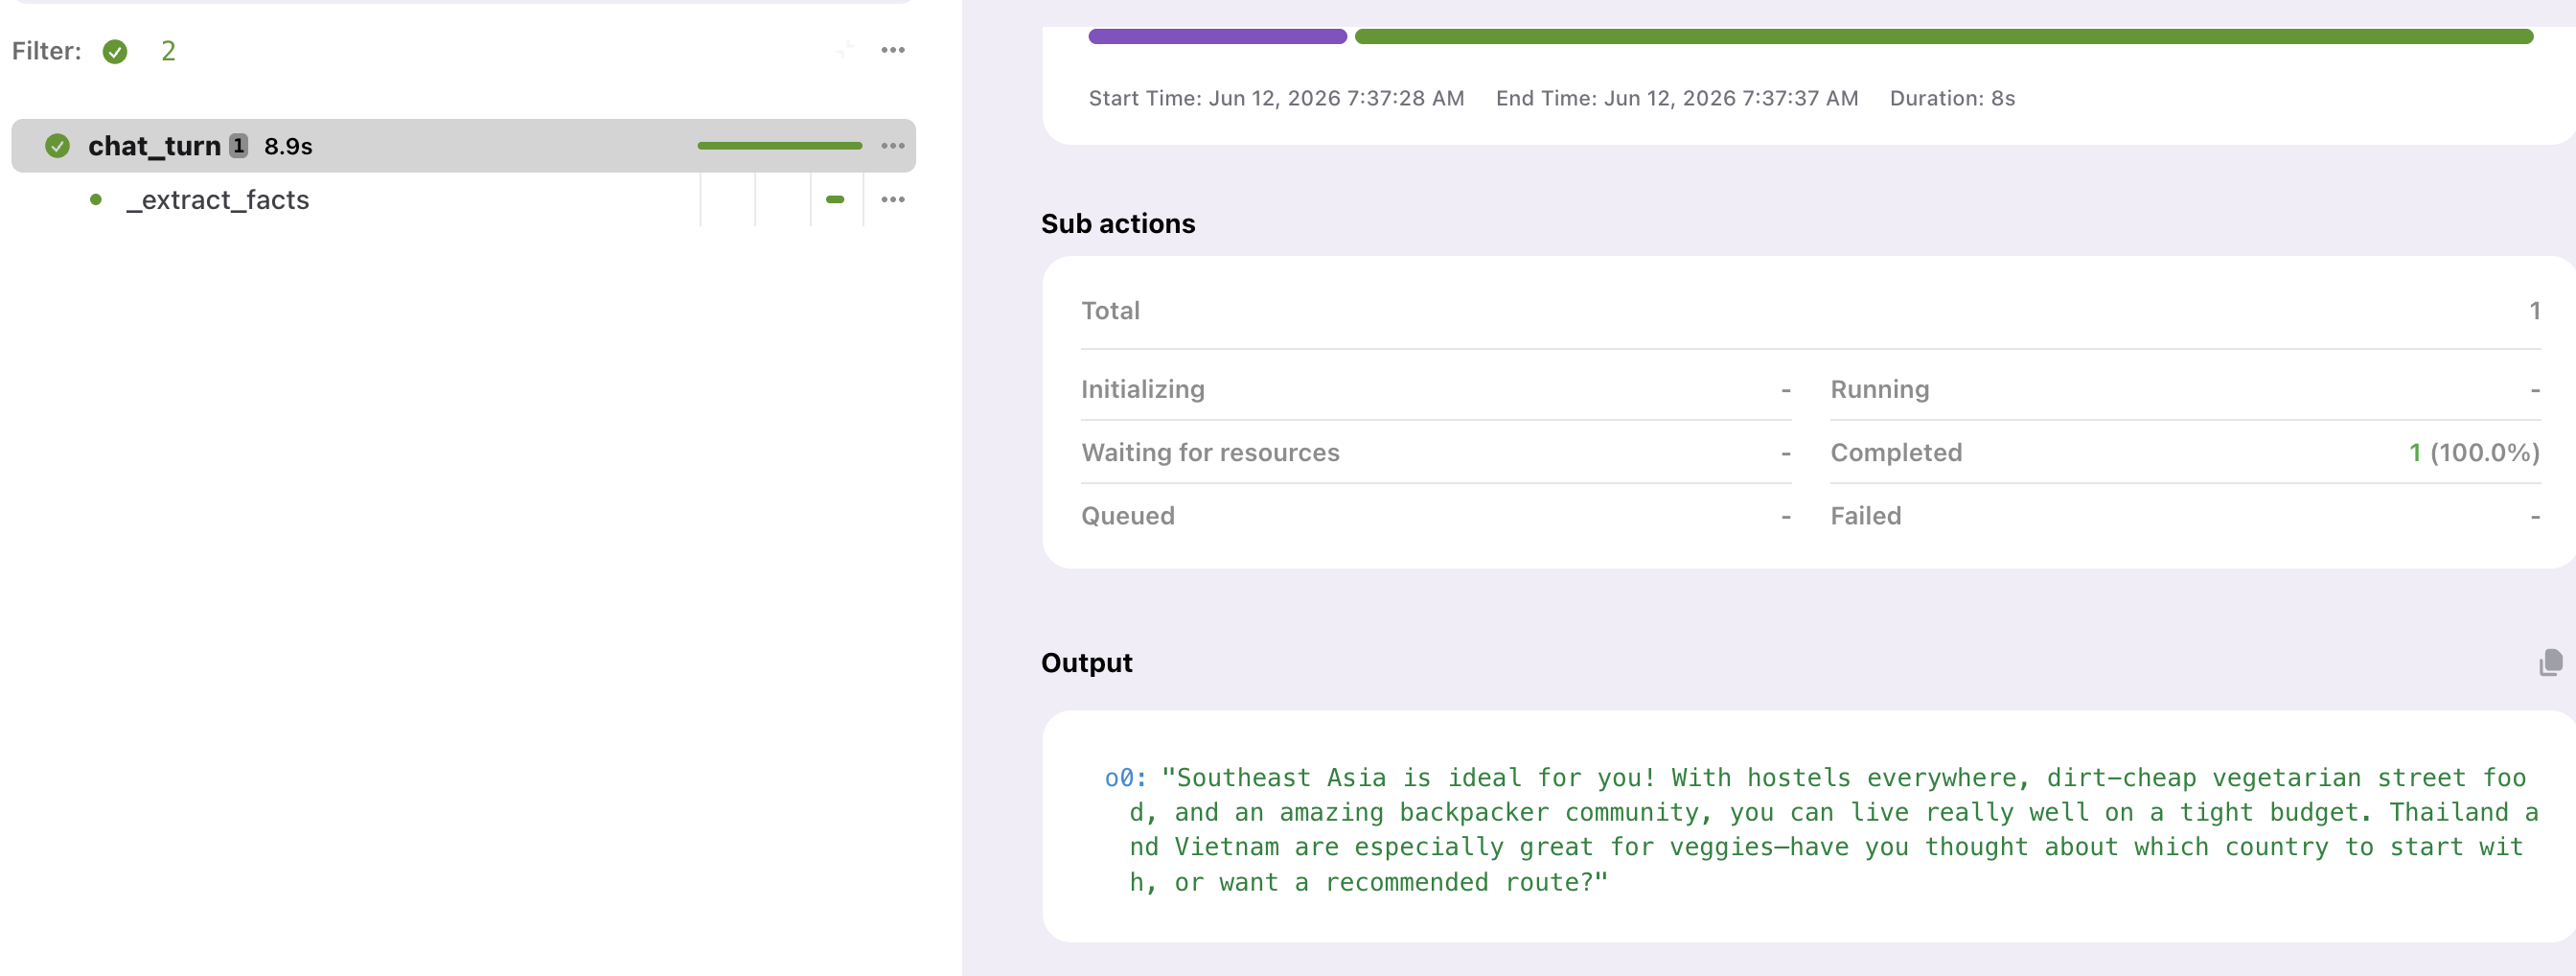

### Inspecting memory state

In [27]:
# Inspect the final memory state by loading the store from inside a task.
# MemoryStore.get_or_create requires a Flyte raw-data context, so we read it
# via a thin wrapper task rather than directly from the notebook.

@memory_env.task(cache=flyte.Cache(behavior="disable"))
async def read_memory(session_key: str) -> str:
    import json as _json
    store = await MemoryStore.get_or_create.aio(key=session_key)
    profile = await store.read_json.aio("profile.json", default={})
    audit = await store.audit_tail(20)
    return _json.dumps({"turns": len(store.messages) // 2, "profile": profile, "audit": audit}, indent=2)

run = await flyte.run.aio(read_memory, session_key=SESSION_KEY)
import json
await run.wait.aio()
state = json.loads(run.outputs()[0])

print(f"Conversation turns stored: {state['turns']}")
print(f"Profile: {state['profile']}")
print(f"\nAudit trail ({len(state['audit'])} events):")
for event in state["audit"]:
    print(f"  {event['ts']}  [{event['op']:6}]  {event['path']}  — {event.get('reason', '')[:50]}")

> Building 1 image...

> Building image memory-agent for environment memory_agent

✓ Built image for environment memory_agent: localhost:30000/memory-agent:c0e0f4726ed0c807007057a3d5d61d37

Output()

Conversation turns stored: 12
Profile: {'name': '', 'preferences': {'accommodation_type': 'hostels', 'budget': 'tight budget', 'budget_level': 'tight budget', 'diet': 'vegetarian', 'dietary_preference': 'vegetarian', 'travel_style': 'hostels and budget travel, vegetarian'}, 'visited_places': ['Tokyo', 'Tokyo', 'Tokyo', 'Tokyo', 'Tokyo']}

Audit trail (12 events):
  2026-06-04T11:02:18+00:00  [create]  profile.json  — I'm a vegetarian, so food options matter a lot to 
  2026-06-12T12:04:47+00:00  [update]  profile.json  — Hi! I'm planning a trip and could use some help.
  2026-06-12T12:20:43+00:00  [update]  profile.json  — Hi! I'm planning a trip and could use some help.
  2026-06-12T12:20:54+00:00  [update]  profile.json  — I love budget travel and prefer hostels over hotel
  2026-06-12T12:21:06+00:00  [update]  profile.json  — I visited Tokyo last year and it was amazing.
  2026-06-12T12:21:16+00:00  [update]  profile.json  — What would you recommend for Southeast Asia on a t
  2026-

### Optimistic concurrency with `expected_sha`

When two writers touch the same artifact, the second should not silently clobber the first. `MemoryStore.write_json` accepts `expected_sha`: the write succeeds only if the file's current sha256 matches. A stale sha raises `ConcurrencyError`, letting the caller reload and retry.

In [ ]:
@memory_env.task(cache=flyte.Cache(behavior="disable"))
async def concurrency_demo(session_key: str) -> str:
    store = await MemoryStore.get_or_create.aio(key=session_key)

    # Writer A creates the file and remembers its sha.
    meta_a = await store.write_json.aio("counter.json", {"n": 1}, actor="writer-A", reason="init")
    stale_sha = meta_a.sha256

    # Writer B advances the file using the current sha — this succeeds.
    await store.write_json.aio(
        "counter.json", {"n": 2}, actor="writer-B", reason="advance", expected_sha=meta_a.sha256
    )

    # Writer A now tries to write with its *stale* sha — this must fail.
    try:
        await store.write_json.aio(
            "counter.json", {"n": 99}, actor="writer-A", reason="stale write", expected_sha=stale_sha
        )
        return "No conflict (unexpected)."
    except ConcurrencyError as exc:
        return f"ConcurrencyError raised as expected: {exc}"


run = await flyte.run.aio(concurrency_demo, session_key="concurrency-demo-1")
await run.wait.aio()
print(run.outputs()[0])